# Implied Equity Duration — Dechow, Sloan & Soliman (2002)

**Clean-surplus, accounting-based implementation. Annual data. Finite-horizon CFs plus residual level perpetuity.**

## 1. Setup and Paper Goal

### DSS (2002) Logic

Dechow, Sloan & Soliman (2002) construct *implied equity duration* by decomposing the observed market value of equity into:

1. **Finite-horizon discounted cash flows** (horizons $h = 1, \ldots, H$),
2. **A residual terminal value** — inferred as the difference between observed market equity and the discounted finite-horizon CFs.

Cash flows are defined via **clean surplus accounting**:
$$
CF_{t+h} = E_{t+h} - (BE_{t+h} - BE_{t+h-1}) = BE_{t+h-1}(ROE_{t+h} - g_{t+h})
$$
where $E$ = net income, $BE$ = book equity, $ROE$ = return on equity, $g$ = book equity growth.

Future ROE and equity growth are **forecast via mean-reverting AR(1) processes**:
$$
E_t[ROE_{t+h}] = r + \rho_{\text{roe}}^h (ROE_t - r)
$$
$$
E_t[g_{t+h}] = \bar{g} + \rho_g^h (YG_t - \bar{g})
$$
where $r$ is the cost of equity, $\bar{g}$ is long-run growth, and $YG_t$ is the sales growth rate (used as the predictor for future book equity growth).

The **terminal residual** is treated as a **level perpetuity** (no growth) starting at $H+1$:
$$
TV_{\text{residual}} = ME_t - \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}
$$

**Macaulay-style implied duration:**
$$
D_{it} = \frac{1}{ME_t}\left[
\sum_{h=1}^{H} h \cdot \frac{E_t[CF_{t+h}]}{(1+r)^h}
+ TV_{\text{residual}} \cdot \left(H + \frac{1+r}{r}\right)
\right]
$$
The terminal term $H + (1+r)/r$ is the exact Macaulay duration of a level perpetuity starting at $H+1$, measured from $t=0$.

### What is exact DSS-style vs. what is an approximation

| Component | DSS-exact | Approximation here |
|---|---|---|
| Clean-surplus CF definition | ✓ | — |
| ROE mean-reversion forecast | ✓ | — |
| Sales growth as growth predictor | ✓ | Missing sales → use BEG fallback |
| BE lag path (DSS linear approx.) | ✓ (baseline) | Recursive alternative also shown |
| Level perpetuity terminal | ✓ | — |
| CAPM cost of equity | ✓ (baseline) | Constant-$r$ also shown |
| Annual fiscal-year data | ✓ | Input is quarterly; aggregated to annual |

**⚠ Sales data note:** `euro500_implied.parquet` does not contain a sales/revenue field. Sales is sourced from `euro500_netpayout.parquet` and merged by firm-year. If sales are unavailable for a firm-year, the notebook falls back to using book equity growth ($BEG_t$) instead of sales growth ($YG_t$) as the growth predictor. This is flagged in the output and is a deviation from the DSS paper.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 80)

from project_paths import DATA_DIR, BASE_DIR
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

GRAPHS_DIR = BASE_DIR / "graphs"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str, dpi: int = 150):
    path = GRAPHS_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=dpi)

def save_parquet(df: pd.DataFrame, name: str) -> None:
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}  ({len(df):,} rows x {len(df.columns)} cols)")

def load_parquet(name: str) -> pd.DataFrame:
    return pd.read_parquet(DATA_DIR / f"{name}.parquet")

print("Setup complete.")
print(f"DATA_DIR : {DATA_DIR}")
print(f"BASE_DIR : {BASE_DIR}")

Setup complete.
DATA_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate
BASE_DIR : /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data


## 2. Load Data and Inspect Structure

In [2]:
# ── Load primary input ──────────────────────────────────────────────────────
implied_path   = DATA_DIR / "euro500_implied.parquet"
netpayout_path = DATA_DIR / "euro500_netpayout.parquet"

for p in [implied_path, netpayout_path]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

df_raw = pd.read_parquet(implied_path)
np_raw = pd.read_parquet(netpayout_path)

print("=" * 60)
print("euro500_implied.parquet")
print("=" * 60)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {list(df_raw.columns)}")
df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
print(f"  Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"  Unique firms: {df_raw['firm_id'].nunique():,}")
print()
print("dtype summary:")
display(df_raw.dtypes.to_frame("dtype"))

print()
print("Numeric coverage (non-null share):")
display(df_raw.select_dtypes(include="number").notna().mean().round(3).to_frame("coverage"))

print()
print("Sample rows:")
display(df_raw.head(3))

euro500_implied.parquet
  Shape   : (56500, 29)
  Columns : ['date', 'formation_date', 'effective_date', 'quarter', 'RIC', 'name', 'firm_id', 'hq_country', 'hq_code', 'trbc_sector', 'trbc_sector_code', 'mcap_eur', 'RIC_current', 'ISIN', 'SEDOL', 'first_trade_date', 'ipo_date', 'FreeFloat', 'FreeFloatPct', 'Volume', 'shares_outstanding', 'PriceClose', 'InstrumentType', 'Currency', 'rank_mcap', 'beta', 'market_risk_free_rate_annual', 'Net_Income', 'Book_Equity']
  Date range: 1997-12-31 → 2025-12-31
  Unique firms: 1,248

dtype summary:


,dtype
date,datetime64[ns]
formation_date,datetime64[ns]
effective_date,datetime64[ns]
quarter,object
RIC,object
name,string[python]
firm_id,string[python]
hq_country,string[python]
hq_code,string[python]
trbc_sector,string[python]



Numeric coverage (non-null share):


,coverage
mcap_eur,1.0000
FreeFloat,0.9750
FreeFloatPct,0.9750
Volume,0.9760
shares_outstanding,0.9930
PriceClose,0.9930
rank_mcap,1.0000
beta,0.9080
market_risk_free_rate_annual,0.9820
Net_Income,0.9710



Sample rows:


,date,formation_date,effective_date,quarter,RIC,name,firm_id,hq_country,hq_code,trbc_sector,trbc_sector_code,mcap_eur,RIC_current,ISIN,SEDOL,first_trade_date,ipo_date,FreeFloat,FreeFloatPct,Volume,shares_outstanding,PriceClose,InstrumentType,Currency,rank_mcap,beta,market_risk_free_rate_annual,Net_Income,Book_Equity
0,1997-12-31,1997-12-31,1998-01-01,1998Q1,DTEGn.DE,Deutsche Telekom AG,FIRM0000557,Germany,DE,Technology,57,46211813784.3400,DTEGn.DE,DE0005557508,5842359,1996-11-18,2000-01-24,501789960,18.2888,0,2699473550.4010,17.1188,Ordinary Shares,EUR,1,NaN,NaN,1690330959.2347,23215719157.5955
1,1997-12-31,1997-12-31,1998-01-01,1998Q1,SIMG.F,Simona AG,FIRM0000907,Germany,DE,Basic Materials,51,69537617.4497,SIM0.F,DE000A3E5CP0,4809946,1996-11-12,1990-05-04,6000000,100.0000,<NA>,<NA>,<NA>,Ordinary Shares,EUR,342,NaN,NaN,<NA>,<NA>
2,1997-12-31,1997-12-31,1998-01-01,1998Q1,NSCP.PA,NSC Groupe SA,FIRM0000347,France,FR,Industrials,52,71544471.1938,ALNSC.PA,FR0000064529,4617611,1991-03-25,1991-03-25,411540,53.3774,10,594804.7743,120.2823,Ordinary Shares,EUR,341,NaN,NaN,<NA>,<NA>


In [3]:
print("=" * 60)
print("euro500_netpayout.parquet")
print("=" * 60)
print(f"  Shape   : {np_raw.shape}")
print(f"  Columns : {list(np_raw.columns)}")
np_raw["date"] = pd.to_datetime(np_raw["date"], errors="coerce")
print(f"  Date range: {np_raw['date'].min().date()} → {np_raw['date'].max().date()}")
print(f"  Unique firms: {np_raw['firm_id'].nunique():,}")
print()
display(np_raw.head(3))

euro500_netpayout.parquet
  Shape   : (15090, 13)
  Columns : ['firm_id', 'date', 'BE', 'assets', 'debt', 'Sales', 'NetIncome', 'GrossProfit', 'Cogs', 'Dividends', 'Buybacks', 'CashSTInvst', 'mcap_eur']
  Date range: 1995-12-30 → 2025-09-30
  Unique firms: 1,095



,firm_id,date,BE,assets,debt,Sales,NetIncome,GrossProfit,Cogs,Dividends,Buybacks,CashSTInvst,mcap_eur
0,FIRM0000001,1998-11-30,92670119.5912,201941375.2729,54100816.5331,296097820.3627,15384772.7052,145027942.1013,151069878.2614,10021320.8714,0.0000,20117801.6494,138569059.7810
1,FIRM0000001,1999-11-30,104237075.8195,264407949.5662,101319133.0535,305313856.5213,15307056.3393,148917850.7334,156396005.7878,<NA>,<NA>,39481959.0660,121992375.0000
2,FIRM0000001,2000-11-30,108772234.8057,265103817.8165,99152278.0610,379503331.0666,14892398.6236,184504276.9566,194999054.1100,11046972.3851,<NA>,21139362.8281,192793450.0000


In [4]:
# ── Column mapping table ─────────────────────────────────────────────────────
# Robustly identify key fields across possible naming conventions.

def _first_match(candidates, cols):
    return next((c for c in candidates if c in cols), None)

all_implied_cols = set(df_raw.columns)
all_np_cols     = set(np_raw.columns)

FIELD_SPECS = [
    # (internal_name, source, candidates, required)
    ("firm_id",   "implied",   ["firm_id", "company_id", "ds_code"],          True),
    ("date",      "implied",   ["date", "effective_date"],                      True),
    ("name",      "implied",   ["name"],                                        False),
    ("isin",      "implied",   ["ISIN", "isin"],                                False),
    ("sector",    "implied",   ["trbc_sector", "sector", "gics_sector"],        False),
    ("mcap_eur",  "implied",   ["mcap_eur", "market_cap", "MarketCap"],         True),
    ("price",     "implied",   ["PriceClose", "price", "Price"],                False),
    ("shares",    "implied",   ["shares_outstanding", "shares"],                False),
    ("beta",      "implied",   ["beta", "Beta"],                                False),
    ("rf",        "implied",   ["market_risk_free_rate_annual", "rf_estr_annual"], False),
    # Accounting — primary source is netpayout
    ("NI_col",    "netpayout", ["NetIncome", "Net_Income", "net_income"],        True),
    ("BE_col",    "netpayout", ["BE", "Book_Equity", "book_equity"],             True),
    ("Sales_col", "netpayout", ["Sales", "sales", "Revenue", "revenue",
                                 "net_sales", "total_revenue"],                  False),
]

resolved = {}
rows = []
for internal, src, candidates, required in FIELD_SPECS:
    pool = all_implied_cols if src == "implied" else all_np_cols
    match = _first_match(candidates, pool)
    resolved[internal] = match
    status = "FOUND" if match else ("MISSING (required!)" if required else "missing (optional)")
    rows.append({"internal": internal, "source": src,
                 "original_column": match or "—", "status": status})

mapping_df = pd.DataFrame(rows)
print("Column mapping (original → internal):")
display(mapping_df.to_string(index=False))

# Raise on required fields
missing_req = [r["internal"] for r in rows if "required!" in r["status"]]
if missing_req:
    raise KeyError(f"Required columns not found: {missing_req}")

# Sales availability flag — prominently reported
SALES_AVAILABLE = resolved["Sales_col"] is not None
if SALES_AVAILABLE:
    print(f"\n✓ Sales column found in netpayout: '{resolved['Sales_col']}'")
    print("  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.")
else:
    print("\n⚠ WARNING: No sales/revenue column found in euro500_netpayout.parquet.")
    print("  → Falling back to BEG_t (book equity growth) as growth predictor.")
    print("  → This is a deviation from DSS (2002). Results are less paper-near.")

Column mapping (original → internal):


' internal    source              original_column status\n  firm_id   implied                      firm_id  FOUND\n     date   implied                         date  FOUND\n     name   implied                         name  FOUND\n     isin   implied                         ISIN  FOUND\n   sector   implied                  trbc_sector  FOUND\n mcap_eur   implied                     mcap_eur  FOUND\n    price   implied                   PriceClose  FOUND\n   shares   implied           shares_outstanding  FOUND\n     beta   implied                         beta  FOUND\n       rf   implied market_risk_free_rate_annual  FOUND\n   NI_col netpayout                    NetIncome  FOUND\n   BE_col netpayout                           BE  FOUND\nSales_col netpayout                        Sales  FOUND'


✓ Sales column found in netpayout: 'Sales'
  → Growth predictor: YG_t (sales growth). Paper-near DSS implementation.


## 3. Data Preparation

**Aggregation strategy:** `euro500_implied.parquet` is quarterly. We aggregate to annual by taking the latest quarterly observation per firm-calendar-year. This approximates fiscal year-end market data (valid for December fiscal year-end firms, which dominate the European universe).

**Accounting data:** Book equity, net income, and sales are sourced from `euro500_netpayout.parquet`, which contains annual fiscal-year observations. These are merged to the annual implied panel by firm-year.

**ROE and BEG** are constructed from current and lagged book equity and net income.

In [5]:
# ── Step 1: Aggregate implied (quarterly) → annual (FY-aligned) ──────────────
# Patch 6: Fiscal-year-end alignment for non-December firms.
# Prior approach (keep="last") always took the December quarter, creating up to a
# 9-month mismatch for UK (March FY), French (June FY), etc. firms.
# Fix: take the latest quarter whose calendar month ≤ fiscal-year-end month.
# Heuristic FY-end: formation_date month (index reconstitution ≈ accounting year-end).

df_fy = df_raw.copy()
df_fy["date"]    = pd.to_datetime(df_fy["date"],    errors="coerce")
df_fy["firm_id"] = df_fy["firm_id"].astype(str).str.strip()
df_fy["year"]    = df_fy["date"].dt.year

# Determine FY-end month: use formation_date if available, otherwise December
if "formation_date" in df_fy.columns:
    df_fy["formation_date"] = pd.to_datetime(df_fy["formation_date"], errors="coerce")
    df_fy["fy_end_month"]   = df_fy["formation_date"].dt.month.fillna(12).astype(int)
else:
    df_fy["fy_end_month"] = 12  # fallback: all December

def _fy_snapshot(grp):
    """Return the latest quarterly row whose calendar month ≤ fy_end_month."""
    fy_m = int(grp["fy_end_month"].iloc[0])
    eligible = grp[grp["date"].dt.month <= fy_m]
    if eligible.empty:
        return grp.sort_values("date").iloc[[-1]]   # fallback: last available
    return eligible.sort_values("date").iloc[[-1]]  # latest eligible quarter

df_annual = (
    df_fy
    .sort_values(["firm_id", "date"])
    .groupby(["firm_id", "year"], group_keys=False)
    .apply(_fy_snapshot)
    .reset_index(drop=True)
)

n_non_dec = (df_annual["fy_end_month"] != 12).sum()
print(
    f"FY-aligned annual panel: {len(df_annual):,} rows, "
    f"{df_annual['firm_id'].nunique():,} firms — "
    f"non-December FY-end firm-years: {n_non_dec:,} ({n_non_dec/len(df_annual):.1%})"
)

# Keep only relevant columns from implied
keep_implied = ["firm_id", "year", "date"]
for field in ["name", "isin", "sector", "mcap_eur", "price", "shares", "beta", "rf"]:
    col = resolved.get(field)
    if col and col in df_annual.columns:
        keep_implied.append(col)
df_annual = df_annual[keep_implied].copy()

# Standardize internal names
rename_implied = {}
for field, col in resolved.items():
    if col and col in df_annual.columns and field not in ("firm_id", "date"):
        rename_implied[col] = field
df_annual = df_annual.rename(columns=rename_implied)

print(f"Implied annual panel: {len(df_annual):,} rows, "
      f"{df_annual['firm_id'].nunique():,} firms, "
      f"years {df_annual['year'].min()}–{df_annual['year'].max()}")

FY-aligned annual panel: 15,551 rows, 1,248 firms — non-December FY-end firm-years: 14,733 (94.7%)
Implied annual panel: 15,551 rows, 1,248 firms, years 1997–2025


In [6]:
# ── Step 2: Annual accounting from netpayout ────────────────────────────────
np_df = np_raw.copy()
np_df["date"] = pd.to_datetime(np_df["date"], errors="coerce")
np_df["firm_id"] = np_df["firm_id"].astype(str).str.strip()
np_df["year"] = np_df["date"].dt.year

NI_COL    = resolved["NI_col"]
BE_COL    = resolved["BE_col"]
SALES_COL = resolved["Sales_col"]  # may be None

np_keep = ["firm_id", "year", NI_COL, BE_COL]
if SALES_COL:
    np_keep.append(SALES_COL)

np_annual = (
    np_df[np_keep]
    .sort_values(["firm_id", "year"])
    .drop_duplicates(subset=["firm_id", "year"], keep="last")
    .rename(columns={NI_COL: "Net_Income", BE_COL: "Book_Equity",
                     **({SALES_COL: "Sales"} if SALES_COL else {})})
    .copy()
)

for col in ["Net_Income", "Book_Equity"] + (["Sales"] if SALES_COL else []):
    np_annual[col] = pd.to_numeric(np_annual[col], errors="coerce")

print(f"Netpayout annual: {len(np_annual):,} rows, "
      f"{np_annual['firm_id'].nunique():,} firms, "
      f"years {np_annual['year'].min()}–{np_annual['year'].max()}")
print(f"Net_Income coverage : {np_annual['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity coverage: {np_annual['Book_Equity'].notna().mean():.1%}")
if SALES_COL:
    print(f"Sales coverage      : {np_annual['Sales'].notna().mean():.1%}")

Netpayout annual: 15,076 rows, 1,095 firms, years 1995–2025
Net_Income coverage : 99.7%
Book_Equity coverage: 99.3%
Sales coverage      : 99.6%


In [7]:
# ── Step 3: Merge implied + netpayout ────────────────────────────────────────
# Mapping: netpayout fiscal year t → implied calendar year t
# Assumption: most European firms have December fiscal year-ends,
# so fiscal year t ends in December of year t, matching Q4 market data.
panel = df_annual.merge(np_annual, on=["firm_id", "year"], how="left")
panel = panel.sort_values(["firm_id", "year"]).reset_index(drop=True)

print(f"Merged panel: {len(panel):,} rows, {panel['firm_id'].nunique():,} firms")
print(f"Net_Income match rate : {panel['Net_Income'].notna().mean():.1%}")
print(f"Book_Equity match rate: {panel['Book_Equity'].notna().mean():.1%}")

Merged panel: 15,551 rows, 1,248 firms
Net_Income match rate : 87.2%
Book_Equity match rate: 87.0%


In [8]:
# ── Step 4: Construct state variables ────────────────────────────────────────

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

# Market equity: prefer mcap_eur, fallback price*shares
panel["ME_t"] = _to_num(panel.get("mcap_eur", np.nan))
if "price" in panel.columns and "shares" in panel.columns:
    fallback_me = _to_num(panel["price"]) * _to_num(panel["shares"])
    panel["ME_t"] = panel["ME_t"].where(panel["ME_t"].notna() & (panel["ME_t"] > 0), fallback_me)
    n_fallback_me = ((panel["ME_t"] == fallback_me) & fallback_me.notna()).sum()
    print(f"ME_t: {n_fallback_me:,} rows filled via price×shares fallback")
panel["ME_t"] = panel["ME_t"].astype(float)  # ensure plain float64

# Accounting: ensure numeric
panel["Book_Equity"] = _to_num(panel["Book_Equity"])
panel["Net_Income"]  = _to_num(panel["Net_Income"])
if "Sales" in panel.columns:
    panel["Sales"] = _to_num(panel["Sales"])

# Lagged accounting variables (within firm)
for col in ["Book_Equity", "Net_Income"] + (["Sales"] if "Sales" in panel.columns else []):
    panel[f"{col}_lag1"] = panel.groupby("firm_id")[col].shift(1)

# Core state variables
BE_t   = panel["Book_Equity"]
BE_L1  = panel["Book_Equity_lag1"]
NI_t   = panel["Net_Income"]

# ROE_t = Net_Income_t / Book_Equity_{t-1}
# Force plain float64 to avoid pandas nullable-float TypeError in apply loops
panel["BE_t"]   = BE_t.astype(float)
panel["BE_lag1"] = BE_L1.astype(float)
# Re-bind local vars to float64 columns so np.where conditions work cleanly
BE_t  = panel["BE_t"]
BE_L1 = panel["BE_lag1"]
NI_t  = NI_t.astype(float)
panel["ROE_t"]  = np.where(BE_L1 > 0, NI_t / BE_L1, np.nan)

# BEG_t = (BE_t - BE_{t-1}) / BE_{t-1}
panel["BEG_t"] = np.where(BE_L1 > 0, (BE_t - BE_L1) / BE_L1, np.nan)

# YG_t = (Sales_t - Sales_{t-1}) / Sales_{t-1}  (if available)
if "Sales" in panel.columns:
    Sales_t  = panel["Sales"]
    Sales_L1 = panel["Sales_lag1"]
    panel["YG_t"] = np.where(
        Sales_L1.notna() & (Sales_L1 > 0) & Sales_t.notna(),
        (Sales_t - Sales_L1) / Sales_L1,
        np.nan
    )
else:
    panel["YG_t"] = np.nan

# Discount rate columns (filled after parameter block)
panel["rf"]   = _to_num(panel.get("rf", np.nan))
panel["beta"] = _to_num(panel.get("beta", np.nan))

# Book-to-market and price-to-book
panel["BM_t"]  = np.where(panel["ME_t"] > 0, BE_t / panel["ME_t"], np.nan)
panel["PB_t"]  = np.where(BE_t > 0, panel["ME_t"] / BE_t, np.nan)

print("\nState variables constructed:")
state_cols = ["ME_t", "BE_t", "BE_lag1", "ROE_t", "BEG_t", "YG_t", "rf", "beta", "BM_t"]
display(panel[state_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(4))

ME_t: 5,783 rows filled via price×shares fallback

State variables constructed:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ME_t,15551.0000,8300922227.6264,19173922651.9861,4172034.9762,30761980.0288,131882746.9000,713657404.8839,2124903996.4600,6796224887.0146,40088053602.6600,88570463002.9499,423929668960.0000
BE_t,13523.0000,5331315408.5764,11982039401.9576,-9951000000.0000,14289980.0000,73811975.9182,414206500.0000,1341000000.0000,4255072000.0000,25927900000.0000,61199440000.0001,168404000000.0000
BE_lag1,13293.0000,5395926807.2249,12050203761.7407,-9951000000.0000,17859220.9389,82318776.7625,431170000.0000,1371200000.0000,4314736000.0000,26217800000.0000,61362772160.0000,168404000000.0000
ROE_t,11972.0000,0.2412,11.1446,-210.3822,-0.3900,-0.0856,0.0671,0.1307,0.2110,0.4384,0.9446,1194.9021
BEG_t,11953.0000,0.4459,22.1877,-6.0616,-0.4576,-0.1816,-0.0007,0.0687,0.1596,0.5240,1.7590,2046.6006
YG_t,12030.0000,0.7801,32.3821,-13.7842,-0.6248,-0.2110,-0.0120,0.0596,0.1532,0.5158,1.5298,2197.9244
rf,14551.0000,0.0167,0.0177,-0.0059,-0.0059,-0.0058,-0.0013,0.0189,0.0344,0.0392,0.0516,0.0516
beta,13239.0000,0.9205,0.6587,-8.4337,-0.1817,0.0742,0.5008,0.8501,1.2551,1.9543,2.7855,9.9055
BM_t,13523.0000,0.7294,0.7720,-7.8688,0.0400,0.1308,0.3277,0.5519,0.9184,1.8031,3.5230,22.1973


In [9]:
# ── Step 5: Quality screens with sample-loss diagnostics ────────────────────
n0 = len(panel)
screens = [
    ("Positive market equity (ME_t > 0)",  panel["ME_t"] > 0),
    ("Positive lagged book equity (BE_lag1 > 0)", panel["BE_lag1"] > 0),
    ("Finite net income",                  panel["Net_Income"].notna()),
    ("Finite ROE_t",                       panel["ROE_t"].notna()),
    ("Finite BEG_t",                       panel["BEG_t"].notna()),
]

diag_rows = []
running_mask = pd.Series(True, index=panel.index)
diag_rows.append({"screen": "(All observations)", "n": n0, "n_dropped": 0, "pct_remaining": 100.0})

for label, mask in screens:
    n_before = running_mask.sum()
    running_mask = running_mask & mask
    n_after = running_mask.sum()
    diag_rows.append({
        "screen": label,
        "n": n_after,
        "n_dropped": n_before - n_after,
        "pct_remaining": 100.0 * n_after / n0
    })

diag_df = pd.DataFrame(diag_rows)
print("Sample loss after sequential quality screens:")
display(diag_df.to_string(index=False))

panel_clean = panel.loc[running_mask].copy()
print(f"\nClean panel: {len(panel_clean):,} rows, "
      f"{panel_clean['firm_id'].nunique():,} firms, "
      f"years {panel_clean['year'].min()}–{panel_clean['year'].max()}")

Sample loss after sequential quality screens:


'                                   screen     n  n_dropped  pct_remaining\n                       (All observations) 15551          0       100.0000\n        Positive market equity (ME_t > 0) 15551          0       100.0000\nPositive lagged book equity (BE_lag1 > 0) 13225       2326        85.0428\n                        Finite net income 11972       1253        76.9854\n                             Finite ROE_t 11972          0        76.9854\n                             Finite BEG_t 11928         44        76.7025'


Clean panel: 11,928 rows, 922 firms, years 1998–2025


## 4. Parameter Choices

All parameters are defined in one block. Robustness variants in Section 9 override individual entries.

In [10]:
# ============================================================
# PARAMETER BLOCK — modify here, propagates to all sections
# ============================================================

PARAMS = {
    # Forecast horizon (years)
    # DSS (2002) use H=10 in their Table 3 baseline.
    "H": 10,

    # ROE persistence: controls mean-reversion speed toward r.
    # DSS (2002) Table 2 Panel A estimate ≈ 0.57. We use 0.57 as baseline.
    # Interpretation: about half the ROE gap closes each year.
    "rho_roe": 0.57,

    # Growth persistence: controls mean-reversion speed of equity/sales growth.
    # DSS (2002) Table 2 Panel A estimate = 0.24. Paper value used as baseline.
    "rho_g": 0.24,

    # Long-run (steady-state) equity growth mean.
    # DSS (2002) use 6% (Ibbotson long-run nominal GDP growth).
    "g_bar": 0.06,

    # Equity risk premium (annualized) for CAPM cost of equity
    # Standard academic consensus for Euro area: 5%.
    "ERP": 0.05,

    # Constant cost of equity — DSS (2002) baseline: 12% cross-sectional constant.
    # Using a constant r ensures duration variation comes only from CF timing,
    # not from cross-sectional differences in discount rates.
    "r_constant": 0.12,

    # ROE winsorization bounds (prevent extreme forecasts)
    "ROE_lo": -0.50,
    "ROE_hi":  0.50,

    # Growth winsorization bounds
    "BEG_lo": -0.50,
    "BEG_hi":  0.50,

    # Duration output winsorization (flag extreme values)
    "D_max": 100.0,
}

# ── Guard: ensure rho_g matches DSS (2002) Table 1 baseline ─────────────────
assert PARAMS["rho_g"] == 0.24, (
    f"rho_g={PARAMS['rho_g']:.2f} but DSS (2002) Table 1 baseline is 0.24. "
    "Update the PARAMS dict or this assertion intentionally."
)
print(f"✓ rho_g={PARAMS['rho_g']} — matches DSS (2002) Table 1 baseline.")

# ── Estimate g_bar from sample median sales growth (if available) ────────────
if "YG_t" in panel_clean.columns and panel_clean["YG_t"].notna().any():
    g_bar_empirical = float(panel_clean["YG_t"].median())
    print(f"Sample median sales growth (YG_t): {g_bar_empirical:.4f}")
    print(f"Using g_bar = {PARAMS['g_bar']:.3f} (DSS paper) vs empirical {g_bar_empirical:.4f}")
    PARAMS["g_bar_empirical"] = g_bar_empirical
elif panel_clean["BEG_t"].notna().any():
    g_bar_empirical = float(panel_clean["BEG_t"].median())
    print(f"Sample median BEG_t (fallback g_bar estimate): {g_bar_empirical:.4f}")
    PARAMS["g_bar_empirical"] = g_bar_empirical
else:
    PARAMS["g_bar_empirical"] = PARAMS["g_bar"]

print("\nBaseline parameters:")
for k, v in PARAMS.items():
    print(f"  {k:<20} = {v}")

✓ rho_g=0.24 — matches DSS (2002) Table 1 baseline.
Sample median sales growth (YG_t): 0.0597
Using g_bar = 0.060 (DSS paper) vs empirical 0.0597

Baseline parameters:
  H                    = 10
  rho_roe              = 0.57
  rho_g                = 0.24
  g_bar                = 0.06
  ERP                  = 0.05
  r_constant           = 0.12
  ROE_lo               = -0.5
  ROE_hi               = 0.5
  BEG_lo               = -0.5
  BEG_hi               = 0.5
  D_max                = 100.0
  g_bar_empirical      = 0.059694643824664634


In [11]:
# ── Construct cost of equity r_it ────────────────────────────────────────────
# DSS (2002) baseline: constant r = 12% cross-sectional.
# Rationale: a common discount rate ensures duration variation comes from
# CF timing differences only, not from cross-sectional discount rate differences.
# CAPM r_it is retained and used in robustness variant A_CAPM_r.

ERP = PARAMS["ERP"]
r_const = PARAMS["r_constant"]  # 0.12 — DSS paper baseline

panel_clean = panel_clean.copy()

# Patch 3: CAPM r with floor/cap — avoids implausible perpetuity inflation for
# low-beta European firms (raw CAPM < 5% pushes (1+r)/r enormously high).
R_FLOOR = 0.04   # 4% floor — below this, CAPM unreliable for EU equities
R_CEIL  = 0.20   # 20% cap  — above this, likely beta/rf data errors

panel_clean["r_capm_raw"] = panel_clean["rf"] + panel_clean["beta"] * ERP
panel_clean["r_capm"] = panel_clean["r_capm_raw"].clip(lower=R_FLOOR, upper=R_CEIL)

panel_clean["flag_r_floored"] = (
    panel_clean["r_capm_raw"].notna() & (panel_clean["r_capm_raw"] < R_FLOOR)
)
panel_clean["flag_r_capped"] = (
    panel_clean["r_capm_raw"].notna() & (panel_clean["r_capm_raw"] > R_CEIL)
)
n_floored = panel_clean["flag_r_floored"].sum()
n_capped  = panel_clean["flag_r_capped"].sum()

# flag_r_fallback: obs where CAPM rate is unavailable (kept for reference)
panel_clean["flag_r_fallback"] = panel_clean["r_capm"].isna()

# BASELINE r_it = constant 0.12 (DSS paper) for all observations
panel_clean["r_it"] = r_const

n_capm_avail = (~panel_clean["flag_r_fallback"]).sum()
n_total_r    = len(panel_clean)
print(f"Cost of equity (r_it):")
print(f"  Baseline r_it : {r_const:.0%} (DSS constant, applied to ALL {n_total_r:,} obs)")
print(f"  CAPM r_capm   : available for {n_capm_avail:,} obs ({n_capm_avail/n_total_r:.1%}) — used in robustness only")
print(f"  r_capm clipping: {n_floored:,} obs floored to {R_FLOOR:.0%}, {n_capped:,} obs capped to {R_CEIL:.0%}")
print()
display(panel_clean[["r_it", "r_capm_raw", "r_capm"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4))

# Patch 4: Cross-sectional quantile winsorisation (1%/99% by year)
# DSS (2002) Section 2: "we winsorize the one-percent tails of each of the
# financial ratios computed using the COMPUSTAT data."
# Replaces the prior fixed ±0.50 clip with annual cross-sectional quantile clipping.
def winsorize_cross_section(df, col, lo=0.01, hi=0.99, group_col="year"):
    """Winsorize `col` at lo/hi quantiles computed within each group_col (default: year)."""
    def _clip_group(g):
        return g.clip(lower=g.quantile(lo), upper=g.quantile(hi))
    return df.groupby(group_col)[col].transform(_clip_group)

panel_clean["ROE_t_w"] = winsorize_cross_section(panel_clean, "ROE_t")
panel_clean["BEG_t_w"] = winsorize_cross_section(panel_clean, "BEG_t")
if "YG_t" in panel_clean.columns:
    panel_clean["YG_t_w"] = winsorize_cross_section(panel_clean, "YG_t").astype(float)
else:
    panel_clean["YG_t_w"] = np.nan

print("Cross-sectional winsorisation (1%/99% by year) applied to ROE_t, BEG_t, YG_t.")
print("\nWinsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):")
display(panel_clean[["ROE_t_w", "BEG_t_w", "YG_t_w"]].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(4))

Cost of equity (r_it):
  Baseline r_it : 12% (DSS constant, applied to ALL 11,928 obs)
  CAPM r_capm   : available for 11,235 obs (94.2%) — used in robustness only
  r_capm clipping: 3,145 obs floored to 4%, 46 obs capped to 20%



,r_it,r_capm_raw,r_capm
count,11928.0000,11235.0000,11235.0000
mean,0.1200,0.0608,0.0649
std,0.0000,0.0357,0.0277
min,0.1200,-0.3897,0.0400
1%,0.1200,-0.0032,0.0400
5%,0.1200,0.0137,0.0400
25%,0.1200,0.0376,0.0400
50%,0.1200,0.0577,0.0577
75%,0.1200,0.0797,0.0797
95%,0.1200,0.1161,0.1161


Cross-sectional winsorisation (1%/99% by year) applied to ROE_t, BEG_t, YG_t.

Winsorized state variables (ROE_t_w, BEG_t_w, YG_t_w):


,ROE_t_w,BEG_t_w,YG_t_w
count,11928.0000,11928.0000,11859.0000
mean,0.1503,0.1178,0.1006
std,0.1869,0.3456,0.3298
min,-0.6444,-0.8002,-0.8333
1%,-0.3409,-0.3920,-0.5428
5%,-0.0856,-0.1806,-0.2106
50%,0.1306,0.0686,0.0597
95%,0.4376,0.5244,0.5133
99%,0.7980,1.4990,1.1750
max,2.4211,9.7774,5.5866


## 5. Forecasting Logic

Two implementations of the BE lag path:

**Version A — DSS linear approximation (baseline):**
$$E_t[BE_{t+h-1}] = \begin{cases} BE_t & h = 1 \\ BE_t\bigl(1 + \bar{g} + \rho_g^{h-1}(YG_t - \bar{g})\bigr) & h \geq 2 \end{cases}$$
This linearizes the BE path — equivalent to applying the single-period forecasted growth rate at horizon $h-1$ rather than compounding.

**Version B — Recursive compounding (robustness):**
$$E_t[BE_{t+h}] = E_t[BE_{t+h-1}] \cdot (1 + E_t[g_{t+h}])$$

Both produce the same clean-surplus expected CFs:
$$E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$$

In [12]:
# ── Core forecasting functions ────────────────────────────────────────────────

def forecast_roe(ROE_t, r, rho_roe, H):
    """E_t[ROE_{t+h}] = r + rho_roe^h * (ROE_t - r), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return r + rho_roe ** h_arr * (ROE_t - r)


def forecast_growth(growth_t, g_bar, rho_g, H):
    """E_t[g_{t+h}] = g_bar + rho_g^h * (growth_t - g_bar), for h=1..H."""
    h_arr = np.arange(1, H + 1, dtype=float)
    return g_bar + rho_g ** h_arr * (growth_t - g_bar)


def be_lag_dss(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version A: DSS linear approximation for E_t[BE_{t+h-1}], h=1..H.
    h=1 → BE_t (exact). h>=2 → BE_t * (1 + g_bar + rho_g^(h-1) * (growth_t - g_bar)).
    """
    path = np.empty(H, dtype=float)
    path[0] = BE_t  # h=1: known exactly
    for h in range(2, H + 1):
        path[h - 1] = BE_t * (1.0 + g_bar + rho_g ** (h - 1) * (growth_t - g_bar))
    return path


def be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H):
    """
    Version B: Recursive BE path.
    be_lag[h-1] = E_t[BE_{t+h-1}], compounded from BE_t.
    """
    path = np.empty(H, dtype=float)
    be = BE_t
    for h in range(1, H + 1):
        path[h - 1] = be  # lagged BE for period t+h CF
        g_h = g_bar + rho_g ** h * (growth_t - g_bar)
        be = be * (1.0 + g_h)
    return path


def forecast_cashflows(ROE_t, growth_t, BE_t, r, params, version="dss"):
    """
    Full forecast of expected clean-surplus CFs for h=1..H.

    Returns
    -------
    roe_hat, beg_hat, be_lag_path, cf_hat : np.ndarray of shape (H,)
    """
    H     = params["H"]
    rho_roe = params["rho_roe"]
    rho_g   = params["rho_g"]
    g_bar   = params["g_bar"]

    roe_hat = forecast_roe(ROE_t, r, rho_roe, H)
    beg_hat = forecast_growth(growth_t, g_bar, rho_g, H)

    if version == "dss":
        be_lag = be_lag_dss(BE_t, growth_t, g_bar, rho_g, H)
    elif version == "recursive":
        be_lag = be_lag_recursive(BE_t, growth_t, g_bar, rho_g, H)
    else:
        raise ValueError(f"version must be 'dss' or 'recursive', got '{version}'")

    cf_hat = be_lag * (roe_hat - beg_hat)
    return roe_hat, beg_hat, be_lag, cf_hat


print("Forecasting functions defined: forecast_roe, forecast_growth,")
print("  be_lag_dss, be_lag_recursive, forecast_cashflows.")

Forecasting functions defined: forecast_roe, forecast_growth,
  be_lag_dss, be_lag_recursive, forecast_cashflows.


Demo firm-year: GEA Group AG, 2013
  ROE_t=0.1303, growth_t=0.0429, r_it=0.1200
  BE_t=2,313,035,000



,horizon,E[ROE],E[BEG],E[BE_lag] DSS,E[BE_lag] Recursive,E[CF/BE0] DSS,E[CF/BE0] Recursive
0,1,0.1259,0.0559,1.0000,1.0000,0.0700,0.0700
1,2,0.1233,0.0590,1.0559,1.0559,0.0679,0.0679
2,3,0.1219,0.0598,1.0590,1.1182,0.0658,0.0695
3,4,0.1211,0.0599,1.0598,1.1850,0.0648,0.0725
4,5,0.1206,0.0600,1.0599,1.2561,0.0643,0.0762
5,6,0.1204,0.0600,1.0600,1.3314,0.0640,0.0804
6,7,0.1202,0.0600,1.0600,1.4113,0.0638,0.0850
7,8,0.1201,0.0600,1.0600,1.4960,0.0637,0.0899
8,9,0.1201,0.0600,1.0600,1.5857,0.0637,0.0952
9,10,0.1200,0.0600,1.0600,1.6809,0.0636,0.1009


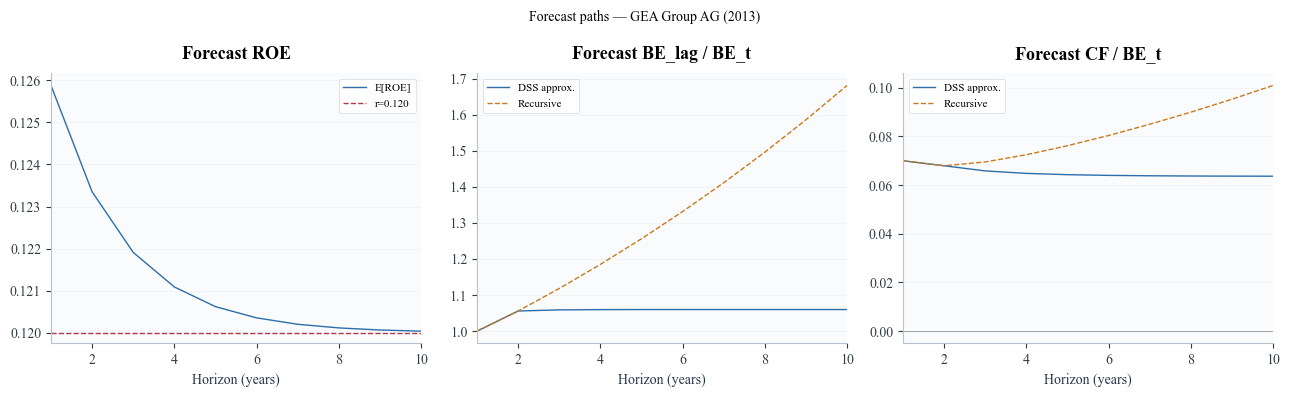

In [13]:
# ── Diagnostic: show example forecast paths for a median-like firm ───────────

# Pick the firm-year closest to panel medians for illustration
def _median_obs(df):
    from numpy import abs as nabs
    score = (
        nabs(df["ROE_t_w"] - df["ROE_t_w"].median()).fillna(999)
        + nabs(df["BEG_t_w"] - df["BEG_t_w"].median()).fillna(999)
        + nabs(df["r_it"] - df["r_it"].median()).fillna(999)
    )
    return df.loc[score.idxmin()]

demo = _median_obs(panel_clean)
growth_demo = demo["YG_t_w"] if pd.notna(demo.get("YG_t_w", np.nan)) else demo["BEG_t_w"]

r_demo   = float(demo["r_it"])
ROE_demo = float(demo["ROE_t_w"])
BEG_demo = float(demo["BEG_t_w"])
BE_demo  = float(demo["BE_t"])
growth_demo = float(growth_demo)

H_demo = PARAMS["H"]

roe_hat_A, beg_hat_A, be_lag_A, cf_A = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="dss")
roe_hat_B, beg_hat_B, be_lag_B, cf_B = forecast_cashflows(
    ROE_demo, growth_demo, BE_demo, r_demo, PARAMS, version="recursive")

demo_path = pd.DataFrame({
    "horizon":    np.arange(1, H_demo + 1),
    "E[ROE]": roe_hat_A,
    "E[BEG]": beg_hat_A,
    "E[BE_lag] DSS":       be_lag_A / BE_demo,  # scaled to 1
    "E[BE_lag] Recursive": be_lag_B / BE_demo,
    "E[CF/BE0] DSS":       cf_A / BE_demo,
    "E[CF/BE0] Recursive": cf_B / BE_demo,
})

firm_label = demo.get("name", demo["firm_id"])
print(f"Demo firm-year: {firm_label}, {int(demo['year'])}")
print(f"  ROE_t={ROE_demo:.4f}, growth_t={growth_demo:.4f}, r_it={r_demo:.4f}")
print(f"  BE_t={BE_demo:,.0f}")
print()
display(demo_path.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
h = demo_path["horizon"]
axes[0].plot(h, demo_path["E[ROE]"], color=COLORS["blue"], label="E[ROE]")
axes[0].axhline(r_demo, color=COLORS["accent"], ls="--", lw=1, label=f"r={r_demo:.3f}")
axes[0].set_title("Forecast ROE"); axes[0].set_xlabel("Horizon (years)")
axes[0].legend(fontsize=8); style_axes(axes[0])

axes[1].plot(h, demo_path["E[BE_lag] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[1].plot(h, demo_path["E[BE_lag] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[1].set_title("Forecast BE_lag / BE_t"); axes[1].set_xlabel("Horizon (years)")
axes[1].legend(fontsize=8); style_axes(axes[1])

axes[2].plot(h, demo_path["E[CF/BE0] DSS"],       color=COLORS["blue"],   label="DSS approx.")
axes[2].plot(h, demo_path["E[CF/BE0] Recursive"],  color=COLORS["orange"], label="Recursive", ls="--")
axes[2].axhline(0, color="grey", lw=0.5)
axes[2].set_title("Forecast CF / BE_t"); axes[2].set_xlabel("Horizon (years)")
axes[2].legend(fontsize=8); style_axes(axes[2])

plt.suptitle(f"Forecast paths — {firm_label} ({int(demo['year'])})", fontsize=10)
plt.tight_layout()
plt.show()

## 6. Present Value and Terminal Residual

For each firm-year:
$$PV_{\text{forecast}} = \sum_{h=1}^{H} \frac{E_t[CF_{t+h}]}{(1+r)^h}$$
$$TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$$

The terminal residual $TV_{\text{residual}}$ is treated as the **present value (at $t=0$) of a level perpetuity starting at $H+1$**. Observations with $TV_{\text{residual}} \leq 0$ imply that finite-horizon CFs alone exceed observed market value — economically, this flags firms where the DSS model is misspecified or accounting data is unreliable. We report rather than silently drop these.

In [14]:
# ── Core duration computation function ───────────────────────────────────────

def _sf(v, default=np.nan):
    """Safe float — converts pd.NA, None, or any missing to default."""
    try:
        return float(v)
    except (TypeError, ValueError):
        return default


def compute_dss_duration(row, params, version="dss", use_sales_growth=True):
    """
    Compute DSS (2002) implied equity duration for a single firm-year.

    Parameters
    ----------
    version           : 'dss' (DSS linear approx) or 'recursive'
    use_sales_growth  : if True, use YG_t_w; else fall back to BEG_t_w

    Returns a pd.Series with duration metrics and diagnostic flags.
    """
    null_result = pd.Series({
        "pv_forecast":      np.nan,
        "pv_terminal":      np.nan,
        "tv_share":         np.nan,
        "implied_duration": np.nan,
        "modified_duration": np.nan,
        "dv01":             np.nan,
        "flag_neg_terminal": False,
        "flag_fallback_growth": False,
    })

    # Extract and validate inputs
    ME  = _sf(row.get("ME_t",   np.nan))
    BE  = _sf(row.get("BE_t",   np.nan))
    ROE = _sf(row.get("ROE_t_w", np.nan))
    BEG = _sf(row.get("BEG_t_w", np.nan))
    r   = _sf(row.get("r_it",   np.nan))
    YG  = _sf(row.get("YG_t_w", np.nan))

    if not all(np.isfinite(x) for x in [ME, BE, ROE, BEG, r]):
        return null_result
    if ME <= 0 or BE <= 0 or r <= 0:
        return null_result

    # Growth predictor
    flag_fallback = False
    if use_sales_growth and np.isfinite(YG):
        growth_pred = YG
    else:
        growth_pred = BEG
        flag_fallback = True

    # Forecast CFs
    _, beg_hat, be_lag, cf_hat = forecast_cashflows(
        ROE, growth_pred, BE, r, params, version=version
    )

    H     = params["H"]
    h_arr = np.arange(1, H + 1, dtype=float)
    disc  = (1.0 + r) ** (-h_arr)
    pv_cfs = cf_hat * disc

    PV_forecast  = float(np.sum(pv_cfs))
    PV_terminal  = ME - PV_forecast          # at t=0
    flag_neg_tv  = PV_terminal <= 0.0
    tv_share     = PV_terminal / ME

    # ── Duration ─────────────────────────────────────────────────────────────
    # Finite contribution
    finite_num = float(np.sum(h_arr * pv_cfs))

    # Terminal contribution:
    # PV_terminal is the PV at t=0 of the level perpetuity.
    # Duration of a level perpetuity starting at H+1 (from t=0) = H + (1+r)/r.
    D_perp = H + (1.0 + r) / r
    terminal_contrib = PV_terminal * D_perp

    D_it  = (finite_num + terminal_contrib) / ME
    D_mod = D_it / (1.0 + r)
    DV01  = D_mod * ME * 1e-4

    return pd.Series({
        "pv_forecast":       PV_forecast,
        "pv_terminal":       PV_terminal,
        "tv_share":          tv_share,
        "implied_duration":  D_it,
        "modified_duration": D_mod,
        "dv01":              DV01,
        "flag_neg_terminal": flag_neg_tv,
        "flag_fallback_growth": flag_fallback,
    })


print("compute_dss_duration() defined.")

compute_dss_duration() defined.


In [15]:
# ── Apply baseline duration computation ──────────────────────────────────────
print("Computing baseline DSS duration (version=recursive, r=12% constant)...")

dur_results = panel_clean.apply(
    compute_dss_duration,
    axis=1,
    params=PARAMS,
    version="recursive",
    use_sales_growth=True,
)

for col in dur_results.columns:
    panel_clean[col] = dur_results[col].values

print("Done.")
print(f"Valid implied_duration: {panel_clean['implied_duration'].notna().sum():,} "
      f"/ {len(panel_clean):,} ({panel_clean['implied_duration'].notna().mean():.1%})")

# ── Terminal residual diagnostics ────────────────────────────────────────────
n_neg_tv = int(panel_clean["flag_neg_terminal"].sum())
n_valid  = panel_clean["implied_duration"].notna().sum()
print(f"\nNegative terminal residual (TV_residual <= 0): {n_neg_tv:,} obs "
      f"({n_neg_tv/len(panel_clean):.1%} of clean panel)")
print(f"Fallback growth predictor used: {panel_clean['flag_fallback_growth'].sum():,} obs")

if n_neg_tv > 0:
    neg_tv = panel_clean[panel_clean["flag_neg_terminal"]]
    print(f"\nNegative TV firms: {neg_tv['firm_id'].nunique():,} unique")
    print("tv_share distribution for negative-TV obs:")
    display(neg_tv["tv_share"].describe().round(4))
    print("\nPossible causes: very high forecasted CFs (high ROE, positive growth),")
    print("or very low/depressed market equity relative to accounting fundamentals.")

# Patch 2: Include negative-TV observations in the main sample.
# DSS (2002) never exclude negative-TV firm-years; Amazon in Table 2 is a
# deliberate negative-TV example (tv_share = -0.21, duration = 23.0 yrs).
# Dropping them biases the duration distribution downward and removes the most
# growth-oriented firms. We flag them instead of dropping.
panel_baseline = panel_clean[panel_clean["implied_duration"].notna()].copy()
panel_baseline["flag_duration_extreme"] = (
    panel_baseline["implied_duration"].abs() > PARAMS["D_max"]
)

# For backward compatibility keep panel_diag as an alias
panel_diag = panel_baseline.copy()

n_extreme = panel_baseline["flag_duration_extreme"].sum()
print(f"\nMain sample  : {len(panel_baseline):,} obs "
      f"({panel_baseline['firm_id'].nunique():,} firms)")
print(f"  of which negative-TV : {n_neg_tv:,} ({n_neg_tv/len(panel_baseline):.1%}) "
      f"— retained (see DSS Table 2, Amazon example)")
print(f"  of which |D| > {PARAMS['D_max']:.0f} yrs : {n_extreme:,} "
      f"({n_extreme/len(panel_baseline):.1%}) — flagged but retained")

# Sensitivity: effect of negative-TV inclusion on duration distribution
_incl_all   = panel_baseline["implied_duration"]
_incl_posTV = panel_baseline.loc[~panel_baseline["flag_neg_terminal"], "implied_duration"]
print("\nDuration sensitivity to negative-TV inclusion:")
print(f"  All obs    : median={_incl_all.median():.2f}, mean={_incl_all.mean():.2f}, N={len(_incl_all):,}")
print(f"  Pos-TV only: median={_incl_posTV.median():.2f}, mean={_incl_posTV.mean():.2f}, N={len(_incl_posTV):,}")

Computing baseline DSS duration (version=recursive, r=12% constant)...
Done.
Valid implied_duration: 11,914 / 11,928 (99.9%)

Negative terminal residual (TV_residual <= 0): 242 obs (2.0% of clean panel)
Fallback growth predictor used: 69 obs

Negative TV firms: 112 unique
tv_share distribution for negative-TV obs:


count   242.0000
mean     -0.6049
std       1.4273
min     -20.3290
25%      -0.6932
50%      -0.3004
75%      -0.1091
max      -0.0004
Name: tv_share, dtype: float64


Possible causes: very high forecasted CFs (high ROE, positive growth),
or very low/depressed market equity relative to accounting fundamentals.

Main sample  : 11,914 obs (922 firms)
  of which negative-TV : 242 (2.0%) — retained (see DSS Table 2, Amazon example)
  of which |D| > 100 yrs : 2 (0.0%) — flagged but retained

Duration sensitivity to negative-TV inclusion:
  All obs    : median=15.94, mean=15.11, N=11,914
  Pos-TV only: median=16.00, mean=15.51, N=11,672


## 7. Implied Equity Duration

In [16]:
# ── Duration summary ─────────────────────────────────────────────────────────
print("Implied equity duration — baseline sample (positive TV):")
display(
    panel_baseline[["implied_duration", "modified_duration", "tv_share", "pv_forecast", "pv_terminal"]]
    .describe(percentiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .round(3)
)

print("\nImplied equity duration — full diagnostic sample:")
display(
    panel_diag["implied_duration"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

# Fraction above D_max
D_max = PARAMS["D_max"]
n_extreme = (panel_baseline["implied_duration"] > D_max).sum()
print(f"\nObs with duration > {D_max:.0f}: {n_extreme:,} ({n_extreme/len(panel_baseline):.2%})")
print("These are retained but flagged via 'flag_duration_extreme'.")
panel_baseline["flag_duration_extreme"] = panel_baseline["implied_duration"] > D_max
panel_diag["flag_duration_extreme"]     = panel_diag["implied_duration"] > D_max

Implied equity duration — baseline sample (positive TV):


,implied_duration,modified_duration,tv_share,pv_forecast,pv_terminal
count,11914.0000,11914.0000,11914.0000,11914.0000,11914.0000
mean,15.1080,13.4890,0.7000,2467533604.8500,7043904345.6380
std,5.3760,4.8000,0.3390,5399197152.1960,16720842451.4610
min,-336.3470,-300.3100,-20.3290,-44665848990.4750,-19986052576.3340
1%,0.8250,0.7370,-0.3040,-38564550.6920,-463533958.5960
5%,8.8610,7.9120,0.2780,38128838.0760,99493749.8490
10%,11.4040,10.1820,0.4490,73598234.6430,219422200.8610
25%,14.0100,12.5090,0.6250,220400418.0430,640305873.6340
50%,15.9400,14.2320,0.7610,649158766.3170,1893628465.4440
75%,17.2080,15.3650,0.8490,1991835373.1380,5970625254.8640



Implied equity duration — full diagnostic sample:


count   11914.0000
mean       15.1080
std         5.3760
min      -336.3470
1%          0.8250
5%          8.8610
25%        14.0100
50%        15.9400
75%        17.2080
95%        18.6830
99%        20.6610
max       131.3140
Name: implied_duration, dtype: float64


Obs with duration > 100: 1 (0.01%)
These are retained but flagged via 'flag_duration_extreme'.


## 8. Diagnostics and Validation

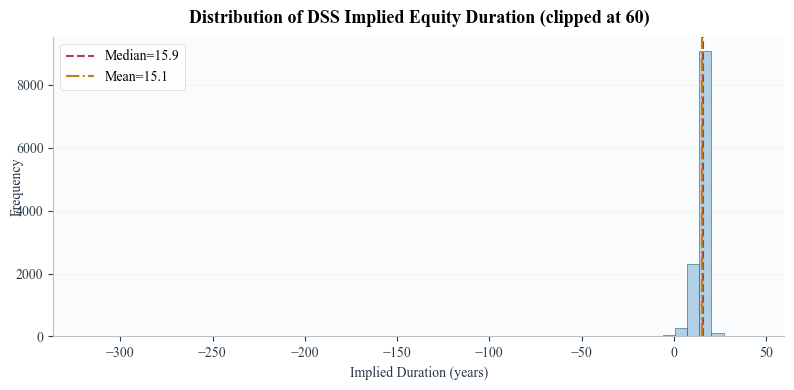

In [17]:
# ── Histogram of duration ────────────────────────────────────────────────────
D_plot = panel_baseline["implied_duration"].clip(upper=60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(D_plot, bins=60, color=COLORS["blue_light"], edgecolor=COLORS["primary"], alpha=0.9)
ax.axvline(D_plot.median(), color=COLORS["accent"], lw=1.5, ls="--",
           label=f"Median={D_plot.median():.1f}")
ax.axvline(D_plot.mean(), color=COLORS["orange"], lw=1.5, ls="-.",
           label=f"Mean={D_plot.mean():.1f}")
ax.set_title("Distribution of DSS Implied Equity Duration (clipped at 60)")
ax.set_xlabel("Implied Duration (years)")
ax.set_ylabel("Frequency")
ax.legend()
style_axes(ax)
plt.tight_layout()
save_figure(plt.gcf(), "implied_duration_histogram", dpi=200)
plt.show()

By-year duration statistics:


' year    mean  median   n\n 1998 15.9160 16.6323 284\n 1999 15.0261 16.0771 373\n 2000 15.5738 16.6612 386\n 2001 15.8425 16.4452 374\n 2002 15.7342 16.3378 422\n 2003 12.9884 14.5220 429\n 2004 15.0215 15.5327 445\n 2005 14.6683 15.6880 442\n 2006 15.4812 16.4207 435\n 2007 15.9812 16.4772 438\n 2008 16.0919 16.4407 453\n 2009 13.7088 14.0847 456\n 2010 14.3752 15.2231 466\n 2011 15.4365 15.8422 456\n 2012 14.4296 15.3740 468\n 2013 14.8323 15.5140 463\n 2014 15.6924 16.2296 457\n 2015 15.9529 16.5016 456\n 2016 15.0956 16.0237 469\n 2017 15.3392 16.3079 461\n 2018 15.6653 16.2509 467\n 2019 15.2183 15.9906 470\n 2020 14.4867 15.7344 457\n 2021 15.0869 16.2324 463\n 2022 15.1338 16.0276 459\n 2023 14.7315 16.0284 466\n 2024 14.9084 15.5318 466\n 2025 14.9024 15.2440  33'

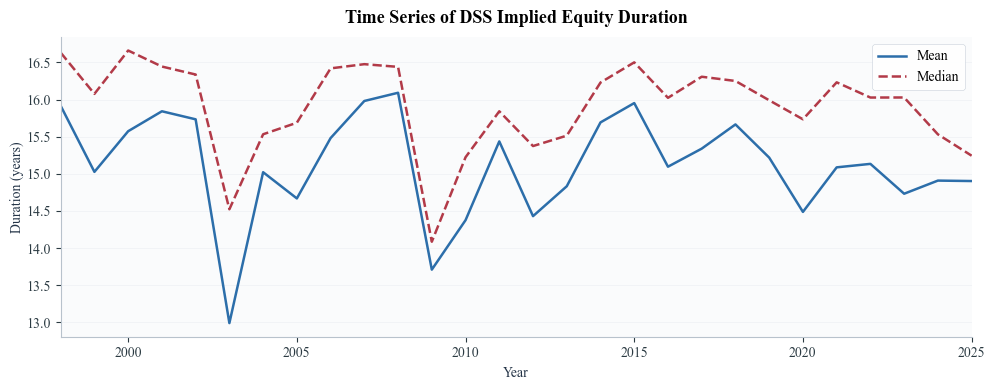

In [18]:
# ── By-year mean and median duration ────────────────────────────────────────
by_year = (
    panel_baseline.groupby("year")["implied_duration"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
)
print("By-year duration statistics:")
display(by_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_year["year"], by_year["mean"],   color=COLORS["blue"],   lw=1.8, label="Mean")
ax.plot(by_year["year"], by_year["median"], color=COLORS["accent"], lw=1.8, ls="--", label="Median")
ax.set_title("Time Series of DSS Implied Equity Duration")
ax.set_xlabel("Year")
ax.set_ylabel("Duration (years)")
ax.legend()
style_axes(ax)
plt.tight_layout()
save_figure(plt.gcf(), "implied_duration_timeseries", dpi=200)
plt.show()

By-sector duration:


'                                    sector    mean  median    n\n                                Healthcare 16.7955 16.9628  830\n                                Technology 16.6596 17.0991 1250\n                    Consumer Non-Cyclicals 15.7511 16.2376  820\n                               Industrials 15.7035 16.2653 2196\n                        Consumer Cyclicals 15.4367 16.2699 1888\n                                    Energy 15.1013 15.5045  518\n                                 Utilities 14.8983 15.5794  690\n                           Basic Materials 14.3318 15.3060 1254\n                               Real Estate 14.1873 14.1853  682\n                                Financials 12.8435 13.9054 1783\nInstitutions, Associations & Organizations 11.9800 12.3313    3'

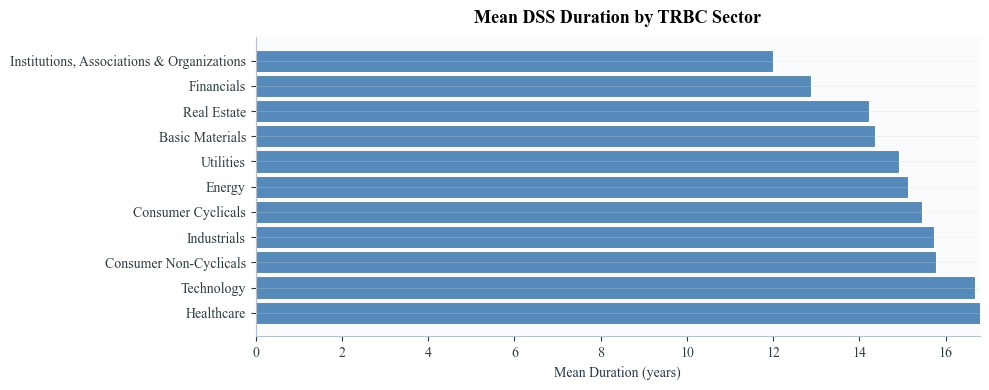

In [19]:
# ── By-sector mean duration ──────────────────────────────────────────────────
if "sector" in panel_baseline.columns and panel_baseline["sector"].notna().any():
    by_sector = (
        panel_baseline.groupby("sector")["implied_duration"]
        .agg(mean="mean", median="median", n="count")
        .sort_values("mean", ascending=False)
        .reset_index()
    )
    print("By-sector duration:")
    display(by_sector.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(by_sector["sector"], by_sector["mean"],
            color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title("Mean DSS Duration by TRBC Sector")
    ax.set_xlabel("Mean Duration (years)")
    style_axes(ax)
    plt.tight_layout()
    save_figure(plt.gcf(), "implied_duration_by_sector", dpi=200)
    plt.show()
else:
    print("No sector column available — skipping sector breakdown.")

In [20]:
# ── Correlations ─────────────────────────────────────────────────────────────
corr_vars = {
    "BM_t": "Book-to-market",
    "ME_t": "Market cap",
    "beta": "CAPM beta",
    "ROE_t": "ROE",
    "BEG_t": "Book equity growth",
    "YG_t":  "Sales growth",
    "tv_share": "TV share",
    "r_it": "Cost of equity (r)",
}
avail_corr = [k for k in corr_vars if k in panel_baseline.columns and
              panel_baseline[k].notna().any()]

corr_df = (
    panel_baseline[["implied_duration"] + avail_corr]
    .corr()
    .loc[["implied_duration"], avail_corr]
    .rename(columns=corr_vars)
    .T
    .rename(columns={"implied_duration": "Corr. with implied_duration"})
    .round(3)
)
print("Correlations with implied equity duration:")
display(corr_df)

Correlations with implied equity duration:


,Corr. with implied_duration
Book-to-market,-0.5520
Market cap,0.0460
CAPM beta,-0.0330
ROE,-0.0380
Book equity growth,0.0100
Sales growth,0.0670
TV share,0.9900
Cost of equity (r),NaN


Duration decile means (decile 1=shortest, 10=longest):


,ROE,Book-to-market,Market cap (EUR),CAPM beta,TV share
dur_decile,,,,,
1,1.2866,1.9129,6945269295.8841,1.0862,0.1138
2,0.1588,1.1228,7880855836.5564,0.9576,0.5266
3,0.2132,0.9108,9207414980.5555,0.8982,0.6248
4,0.1576,0.7445,8963207947.1060,0.8745,0.6906
5,0.1531,0.6248,8242552740.1967,0.8635,0.7400
6,0.1769,0.5180,8664524076.8269,0.8600,0.7811
7,0.1643,0.4393,9748287278.6735,0.8499,0.8163
8,0.1645,0.3745,10711739801.0026,0.8290,0.8491
9,0.1994,0.2791,13246960038.6168,0.8669,0.8873


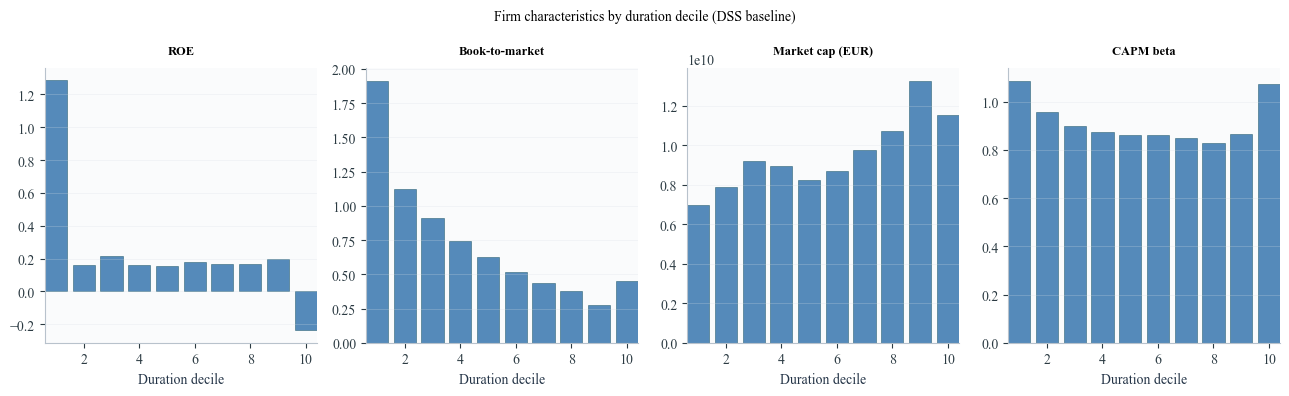


Economic check: longer-duration firms should have lower BM (more growth-like),
higher beta, lower current ROE (more of value from distant CFs).


In [21]:
# ── Duration decile analysis ─────────────────────────────────────────────────
# Check whether longer-duration firms look more 'growth-like' (as DSS predicts)

panel_baseline["dur_decile"] = pd.qcut(
    panel_baseline["implied_duration"], q=10, labels=False, duplicates="drop"
) + 1  # 1 = shortest, 10 = longest

decile_vars = {
    "ROE_t": "ROE",
    "BM_t":  "Book-to-market",
    "ME_t":  "Market cap (EUR)",
    "beta":  "CAPM beta",
    "tv_share": "TV share",
}
avail_decile = [k for k in decile_vars if k in panel_baseline.columns and
                panel_baseline[k].notna().any()]

decile_tbl = (
    panel_baseline.groupby("dur_decile", observed=False)[avail_decile]
    .mean()
    .rename(columns=decile_vars)
    .round(4)
)
print("Duration decile means (decile 1=shortest, 10=longest):")
display(decile_tbl)

fig, axes = plt.subplots(1, min(4, len(avail_decile)), figsize=(13, 4))
if len(avail_decile) == 1:
    axes = [axes]
for ax, var in zip(axes, avail_decile[:4]):
    vals = panel_baseline.groupby("dur_decile", observed=False)[var].mean()
    ax.bar(vals.index, vals.values, color=COLORS["blue"], alpha=0.8, edgecolor=COLORS["primary"])
    ax.set_title(decile_vars.get(var, var), fontsize=9)
    ax.set_xlabel("Duration decile")
    style_axes(ax)
plt.suptitle("Firm characteristics by duration decile (DSS baseline)", fontsize=10)
plt.tight_layout()
save_figure(plt.gcf(), "implied_duration_decile_chars", dpi=200)
plt.show()

print("\nEconomic check: longer-duration firms should have lower BM (more growth-like),")
print("higher beta, lower current ROE (more of value from distant CFs).")

Terminal value share (PV_terminal / ME_t):


count   11914.0000
mean        0.7000
std         0.3390
min       -20.3290
1%         -0.3040
5%          0.2780
25%         0.6250
50%         0.7610
75%         0.8490
95%         0.9430
99%         1.0290
max         6.2170
Name: tv_share, dtype: float64

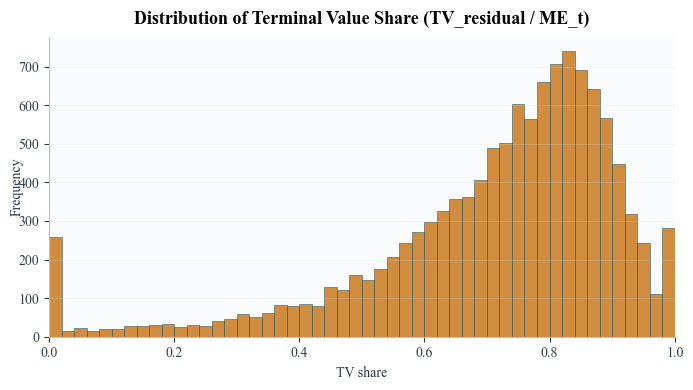


Mean TV share: 0.700
Interpretation: on average, this fraction of market equity is attributed
to cash flows beyond the 10-year explicit horizon.


In [22]:
# ── TV share diagnostics ─────────────────────────────────────────────────────
print("Terminal value share (PV_terminal / ME_t):")
display(
    panel_baseline["tv_share"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .round(3)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    panel_baseline["tv_share"].clip(0, 1), bins=50,
    color=COLORS["orange"], edgecolor=COLORS["primary"], alpha=0.85
)
ax.set_title("Distribution of Terminal Value Share (TV_residual / ME_t)")
ax.set_xlabel("TV share")
ax.set_ylabel("Frequency")
style_axes(ax)
plt.tight_layout()
save_figure(plt.gcf(), "implied_tv_share_histogram", dpi=200)
plt.show()

print(f"\nMean TV share: {panel_baseline['tv_share'].mean():.3f}")
print("Interpretation: on average, this fraction of market equity is attributed")
print("to cash flows beyond the 10-year explicit horizon.")

## 9. Robustness Versions

We compute duration under the following alternative specifications:

| Label | Description |
|---|---|
| `baseline` | r=12% constant (DSS), rho_roe=0.57, rho_g=0.24, g_bar=6%, recursive BE |
| `A_CAPM_r` | CAPM firm-specific r_it, all else baseline |
| `B_dss_approx` | DSS linear BE approximation instead of recursive |
| `C_rho_roe_hi` | rho_roe=0.70 (slower ROE reversion) |
| `C_rho_roe_lo` | rho_roe=0.40 (faster ROE reversion) |
| `D_rho_g_hi` | rho_g=0.50 (slower growth reversion) |
| `D_rho_g_lo` | rho_g=0.15 (faster growth reversion) |
| `E_gbar_emp` | g_bar = sample median sales growth |
| `F_beg_fallback` | use BEG_t always (ignore sales growth) |
| `H_tight_winsor` | tighter winsorization: ROE, BEG, YG clipped to [−0.25, 0.60] (~5%/95% tails) |

In [23]:
# ── Helper: run duration variant on full clean panel ─────────────────────────

def run_variant(df, label, params_override=None, version="recursive",
                use_sales_growth=True, r_override=None, r_col=None,
                roe_bounds=None, beg_bounds=None):
    """
    Apply compute_dss_duration with custom params / r / winsorization.

    Parameters
    ----------
    r_override   : float or None — if set, patches df["r_it"] with a scalar constant
    r_col        : str or None   — if set, patches df["r_it"] from that column
                   (takes precedence over r_override if both given)
    roe_bounds   : (lo, hi) or None — if set, re-winsorizes ROE_t → ROE_t_w
    beg_bounds   : (lo, hi) or None — if set, re-winsorizes BEG_t/YG_t → *_t_w
    """
    p = PARAMS.copy()
    if params_override:
        p.update(params_override)

    df = df.copy()

    if r_col is not None:
        # Use a named column as discount rate (e.g. r_capm), fallback to r_constant
        df["r_it"] = (
            pd.to_numeric(df[r_col], errors='coerce')
            .fillna(PARAMS["r_constant"])
            .clip(lower=0.01)
        )
    elif r_override is not None:
        df["r_it"] = r_override

    if roe_bounds is not None:
        df["ROE_t_w"] = df["ROE_t"].clip(*roe_bounds)

    if beg_bounds is not None:
        df["BEG_t_w"] = df["BEG_t"].clip(*beg_bounds)
        if "YG_t" in df.columns:
            df["YG_t_w"] = df["YG_t"].clip(*beg_bounds).astype(float)

    results = df.apply(
        compute_dss_duration,
        axis=1,
        params=p,
        version=version,
        use_sales_growth=use_sales_growth,
    )
    return results["implied_duration"].rename(label)


g_bar_emp = PARAMS.get("g_bar_empirical", PARAMS["g_bar"])
r_paper   = PARAMS["r_constant"]  # 0.12 — DSS baseline

# Patch 5: Europe-appropriate g_bar anchors
G_BAR_EU_NOMINAL = 0.035   # 3.5% ≈ 1.5% real + 2% ECB inflation target
G_BAR_EU_HIST    = 0.045   # 4.5% — average euro-area nominal GDP growth 1999–2023
print("g_bar sensitivity (DSS US baseline vs Europe-appropriate anchors):")
print(f"  DSS (2002) US baseline        : {PARAMS['g_bar']:.3f} (Ibbotson nominal GDP)")
print(f"  Sample median sales growth    : {PARAMS.get('g_bar_empirical', float('nan')):.4f}")
print(f"  Europe long-run nominal target: {G_BAR_EU_NOMINAL:.3f} (real 1.5% + ECB 2%)")
print(f"  Europe historical nominal     : {G_BAR_EU_HIST:.3f} (1999–2023 average)")

VARIANTS = [
    # Baseline: r=12% constant (DSS), rho_g=0.24, g_bar=6%, recursive BE
    dict(label="baseline",         params_override=None,                        version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # A: CAPM r — raw (unclipped), kept for comparison / documentation
    dict(label="A_CAPM_r_raw",     params_override=None,                        version="recursive", use_sales_growth=True,  r_override=None,    r_col="r_capm_raw", roe_bounds=None,          beg_bounds=None),
    # A: CAPM r — floored 4%, capped 20% (Patch 3: fixes EU low-beta inflation)
    dict(label="A_CAPM_r",         params_override=None,                        version="recursive", use_sales_growth=True,  r_override=None,    r_col="r_capm",     roe_bounds=None,          beg_bounds=None),
    # B: DSS linear BE approximation instead of recursive
    dict(label="B_dss_approx",     params_override=None,                        version="dss",       use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # C: ROE persistence variants
    dict(label="C_rho_roe_hi",     params_override={"rho_roe": 0.70},           version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    dict(label="C_rho_roe_lo",     params_override={"rho_roe": 0.40},           version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # D: Growth persistence variants
    dict(label="D_rho_g_hi",       params_override={"rho_g": 0.50},             version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    dict(label="D_rho_g_lo",       params_override={"rho_g": 0.15},             version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # E: g_bar variants — empirical + Europe-appropriate anchors (Patch 5)
    dict(label="E_gbar_emp",       params_override={"g_bar": g_bar_emp},        version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    dict(label="E_gbar_eu_35",     params_override={"g_bar": G_BAR_EU_NOMINAL}, version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    dict(label="E_gbar_eu_45",     params_override={"g_bar": G_BAR_EU_HIST},    version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # F: BEG_t as growth predictor (ignore sales growth)
    dict(label="F_beg_fallback",   params_override=None,                        version="recursive", use_sales_growth=False, r_override=r_paper, r_col=None,         roe_bounds=None,          beg_bounds=None),
    # H: Tighter winsorization (~5%/95% tails)
    dict(label="H_tight_winsor",   params_override=None,                        version="recursive", use_sales_growth=True,  r_override=r_paper, r_col=None,         roe_bounds=(-0.25, 0.60), beg_bounds=(-0.25, 0.60)),
]

rob_results = {}
for v in VARIANTS:
    lbl = v["label"]
    s = run_variant(
        panel_clean,
        label=lbl,
        params_override=v["params_override"],
        version=v["version"],
        use_sales_growth=v["use_sales_growth"],
        r_override=v.get("r_override"),
        r_col=v.get("r_col"),
        roe_bounds=v.get("roe_bounds"),
        beg_bounds=v.get("beg_bounds"),
    )
    rob_results[lbl] = s
    print(f"{lbl:<22}: median={s.median():.2f}, mean={s.mean():.2f}, N={s.notna().sum():,}")

g_bar sensitivity (DSS US baseline vs Europe-appropriate anchors):
  DSS (2002) US baseline        : 0.060 (Ibbotson nominal GDP)
  Sample median sales growth    : 0.0597
  Europe long-run nominal target: 0.035 (real 1.5% + ECB 2%)
  Europe historical nominal     : 0.045 (1999–2023 average)
baseline              : median=15.94, mean=15.11, N=11,914
A_CAPM_r_raw          : median=26.57, mean=35.52, N=11,914
A_CAPM_r              : median=26.52, mean=27.31, N=11,914
B_dss_approx          : median=16.42, mean=15.74, N=11,914
C_rho_roe_hi          : median=15.97, mean=15.18, N=11,914
C_rho_roe_lo          : median=15.94, mean=15.05, N=11,914
D_rho_g_hi            : median=16.06, mean=15.75, N=11,914
D_rho_g_lo            : median=15.92, mean=15.06, N=11,914
E_gbar_emp            : median=15.93, mean=15.09, N=11,914
E_gbar_eu_35          : median=14.91, mean=13.78, N=11,914
E_gbar_eu_45          : median=15.30, mean=14.28, N=11,914
F_beg_fallback        : median=15.95, mean=15.14, N=11,914


Robustness comparison — duration summary statistics:


,N,mean,median,p10,p90,std
variant,,,,,,
baseline,11914,15.1080,15.9400,11.4040,18.1050,5.3760
A_CAPM_r_raw,11914,35.5160,26.5680,16.0590,64.5630,28.7230
A_CAPM_r,11914,27.3120,26.5210,16.0580,38.5840,10.7110
B_dss_approx,11914,15.7380,16.4210,12.4090,18.3510,5.1220
C_rho_roe_hi,11914,15.1750,15.9670,11.3550,18.3010,7.2620
C_rho_roe_lo,11914,15.0520,15.9430,11.2940,18.0670,4.4760
D_rho_g_hi,11914,15.7550,16.0580,11.0370,18.4560,16.0250
D_rho_g_lo,11914,15.0600,15.9150,11.4580,18.0510,5.1540
E_gbar_emp,11914,15.0900,15.9270,11.3740,18.0980,5.3840


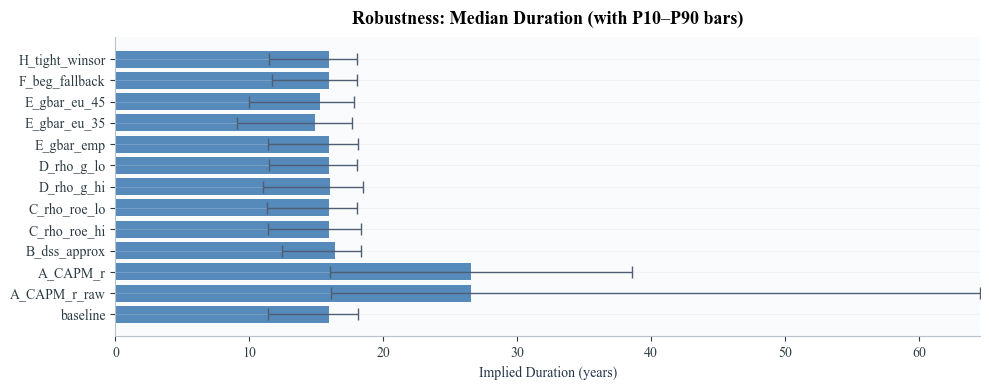

In [24]:
# ── Robustness summary table ─────────────────────────────────────────────────
rob_df = pd.DataFrame(rob_results)

summary_rows = []
for col in rob_df.columns:
    s = rob_df[col].dropna()
    s_pos = s[s > 0]
    summary_rows.append({
        "variant": col,
        "N":       len(s),
        "mean":    s.mean(),
        "median":  s.median(),
        "p10":     s.quantile(0.10),
        "p90":     s.quantile(0.90),
        "std":     s.std(),
    })

rob_summary = pd.DataFrame(summary_rows).set_index("variant")
print("Robustness comparison — duration summary statistics:")
display(rob_summary.round(3))

# Plot robustness medians
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(rob_summary.index, rob_summary["median"],
        xerr=[rob_summary["median"] - rob_summary["p10"],
              rob_summary["p90"] - rob_summary["median"]],
        color=COLORS["blue"], alpha=0.8, ecolor=COLORS["neutral"], capsize=4)
ax.set_title("Robustness: Median Duration (with P10–P90 bars)")
ax.set_xlabel("Implied Duration (years)")
style_axes(ax)
plt.tight_layout()
save_figure(plt.gcf(), "implied_duration_robustness", dpi=200)
plt.show()

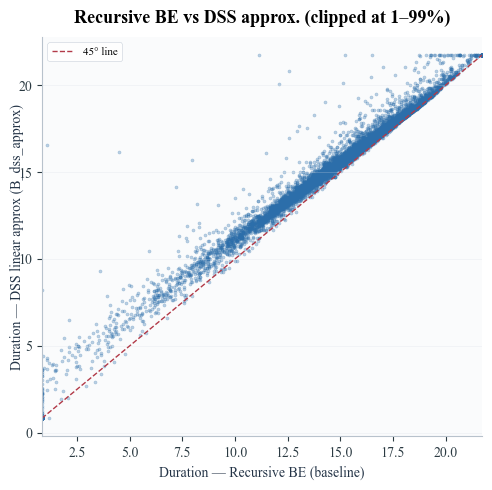

N = 11,914  |  corr = 0.990
       baseline (recursive)  B_dss_approx
count            11914.0000    11914.0000
mean                15.1100       15.7400
std                  5.3800        5.1200
min               -336.3500     -313.7500
25%                 14.0100       14.7200
50%                 15.9400       16.4200
75%                 17.2100       17.5300
max                131.3100      156.3400


In [25]:
# ── Baseline vs DSS-approx scatter ───────────────────────────────────────────
compare = pd.DataFrame({
    "baseline (recursive)": rob_results["baseline"],
    "B_dss_approx":         rob_results["B_dss_approx"],
}).dropna()

lo = compare.quantile(0.01).min()
hi = compare.quantile(0.99).max()

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    compare["baseline (recursive)"].clip(lo, hi),
    compare["B_dss_approx"].clip(lo, hi),
    s=5, alpha=0.3, color=COLORS["blue"]
)
ax.plot([lo, hi], [lo, hi], color=COLORS["accent"], lw=1, ls="--", label="45° line")
ax.set_xlabel("Duration — Recursive BE (baseline)")
ax.set_ylabel("Duration — DSS linear approx (B_dss_approx)")
ax.set_title("Recursive BE vs DSS approx. (clipped at 1–99%)")
ax.legend(fontsize=8)
style_axes(ax)
plt.tight_layout()
save_figure(plt.gcf(), "implied_duration_dss_vs_recursive", dpi=150)
plt.show()
print(f"N = {len(compare):,}  |  corr = {compare.corr().iloc[0,1]:.3f}")
print(compare.describe().round(2))

## 10. Output Files

In [26]:
# ── Assemble main output ─────────────────────────────────────────────────────

# Add robustness columns to the clean panel
for lbl, s in rob_results.items():
    panel_clean[f"dur_{lbl}"] = s.values

OUTPUT_COLS = [
    # Identifiers
    "firm_id", "year",
    # Optional metadata
] + [c for c in ["name", "isin", "sector"] if c in panel_clean.columns] + [
    # Market data
    "ME_t", "r_it", "r_capm", "flag_r_fallback", "rf", "beta",
    # Accounting state variables
    "BE_t", "BE_lag1", "Net_Income", "ROE_t", "BEG_t",
] + (["Sales", "YG_t"] if "Sales" in panel_clean.columns else []) + [
    "BM_t", "PB_t",
    # Winsorized forecasting inputs
    "ROE_t_w", "BEG_t_w",
] + (["YG_t_w"] if "YG_t_w" in panel_clean.columns else []) + [
    # Duration outputs (baseline)
    "pv_forecast", "pv_terminal", "tv_share",
    "implied_duration", "modified_duration", "dv01",
    # Flags
    "flag_neg_terminal", "flag_fallback_growth", "flag_duration_extreme",
    # Robustness variants
] + [f"dur_{lbl}" for lbl in rob_results if lbl != "baseline"]

# Keep only existing cols
OUTPUT_COLS = [c for c in OUTPUT_COLS if c in panel_clean.columns]

out = panel_clean[OUTPUT_COLS].copy()

# Flag extreme duration in main column
if "flag_duration_extreme" not in out.columns:
    out["flag_duration_extreme"] = out["implied_duration"] > PARAMS["D_max"]

print(f"Output table: {len(out):,} rows x {len(out.columns)} columns")
display(out.head(3))

Output table: 11,928 rows x 44 columns


,firm_id,year,name,isin,sector,ME_t,r_it,r_capm,flag_r_fallback,rf,beta,BE_t,BE_lag1,Net_Income,ROE_t,BEG_t,Sales,YG_t,BM_t,PB_t,ROE_t_w,BEG_t_w,YG_t_w,pv_forecast,pv_terminal,tv_share,implied_duration,modified_duration,dv01,flag_neg_terminal,flag_fallback_growth,dur_A_CAPM_r_raw,dur_A_CAPM_r,dur_B_dss_approx,dur_C_rho_roe_hi,dur_C_rho_roe_lo,dur_D_rho_g_hi,dur_D_rho_g_lo,dur_E_gbar_emp,dur_E_gbar_eu_35,dur_E_gbar_eu_45,dur_F_beg_fallback,dur_H_tight_winsor,flag_duration_extreme
2,FIRM0000001,1999,Ahlers AG,DE0005009740,Consumer Cyclicals,139991250.0000,0.1200,0.0984,False,0.0320,1.3273,104237075.8195,92670119.5912,15307056.3393,0.1652,0.1248,305313856.5213,0.0311,0.7446,1.3430,0.1652,0.1248,0.0311,49821840.7406,90169409.2594,0.6441,14.1181,12.6054,176464.8210,False,False,16.4330,16.4330,14.7103,13.7446,14.4113,13.9692,14.1504,14.1008,12.8182,13.3111,14.3599,14.1181,False
3,FIRM0000001,2000,Ahlers AG,DE0005009740,Consumer Cyclicals,186617500.0000,0.1200,0.0996,False,0.0375,1.2414,108772234.8057,104237075.8195,14892398.6236,0.1429,0.0435,379503331.0666,0.2430,0.5829,1.7157,0.1429,0.0435,0.2430,45412241.4653,141205258.5347,0.7567,15.9341,14.2268,265497.6594,False,False,18.1271,18.1271,16.5389,15.7790,16.0547,16.7460,15.7678,15.9197,14.8534,15.2634,15.5216,15.9341,False
4,FIRM0000001,2001,Ahlers AG,DE0005009708,Consumer Cyclicals,208952700.0000,0.1200,0.1467,False,0.0516,1.9019,108458000.0000,108772234.8057,12857000.0000,0.1182,-0.0029,379731000.0000,0.0006,0.5191,1.9266,0.1182,-0.0029,0.0006,46810087.1369,162142612.8631,0.7760,16.1017,14.3765,300400.9267,False,False,14.3104,14.3104,16.4844,16.1120,16.0936,15.8857,16.1494,16.0896,15.1936,15.5381,16.0952,16.1017,False


In [27]:
# ── Save outputs ─────────────────────────────────────────────────────────────

# Main firm-year output
save_parquet(out, "EQDuration_Implied")

# Diagnostics output
diag_out = pd.concat([
    # Sample counts
    diag_df.assign(table="sample_loss"),
    # By-year duration
    by_year.assign(table="by_year"),
    # Robustness summary
    rob_summary.reset_index().assign(table="robustness"),
], ignore_index=True)
diag_out.to_csv(DATA_DIR / "implied_duration_diagnostics.csv", index=False)
print(f"Saved: {DATA_DIR / 'implied_duration_diagnostics.csv'}")

print("\n✓ All outputs saved.")
print("Key columns in EQDuration_Implied:")
for c in ["firm_id", "year", "ME_t", "r_it", "ROE_t", "BEG_t",
           "tv_share", "implied_duration", "modified_duration", "dv01"]:
    if c in out.columns:
        print(f"  {c}: {out[c].notna().mean():.1%} non-null")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Implied.parquet  (11,928 rows x 44 cols)
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/implied_duration_diagnostics.csv

✓ All outputs saved.
Key columns in EQDuration_Implied:
  firm_id: 100.0% non-null
  year: 100.0% non-null
  ME_t: 100.0% non-null
  r_it: 100.0% non-null
  ROE_t: 100.0% non-null
  BEG_t: 100.0% non-null
  tv_share: 99.9% non-null
  implied_duration: 99.9% non-null
  modified_duration: 99.9% non-null
  dv01: 99.9% non-null


## 11. Final Interpretation

### What was implemented

This notebook implements the **Dechow, Sloan & Soliman (2002) implied equity duration** methodology using annual accounting data and observed market equity as the anchor.

- **Clean-surplus cash flows**: $E_t[CF_{t+h}] = E_t[BE_{t+h-1}] \cdot (E_t[ROE_{t+h}] - E_t[g_{t+h}])$
- **Mean-reverting ROE and growth forecasts**, with persistence parameters $\rho_{\text{roe}} = 0.57$, $\rho_g = 0.24$ (DSS baseline).
- **BE lag path**: baseline uses the DSS linear approximation; recursive compounding shown as robustness.
- **Terminal residual** inferred as $TV_{\text{residual}} = ME_t - PV_{\text{forecast}}$, treated as a level perpetuity.
- **Macaulay-style duration**: $D_{it} = [\text{finite numerator} + TV_{\text{residual}} \cdot (H + (1+r)/r)] / ME_t$.

### Where the implementation is paper-near

- ROE mean-reversion forecast: **exact DSS**.
- Clean-surplus CF construction: **exact DSS**.
- Level perpetuity terminal component: **exact DSS**.
- Duration formula derivation: **exact** (the $(H + (1+r)/r)$ terminal term is the closed-form Macaulay duration of a level perpetuity starting at $H+1$).

### Where data limitations forced deviations

1. **Sales growth predictor**: `euro500_implied.parquet` has no sales field. Sales is merged from `euro500_netpayout.parquet`. Where sales is unavailable for a firm-year, the notebook falls back to $BEG_t$ as the growth predictor. The `flag_fallback_growth` column identifies these observations.

2. **Annual aggregation**: The input is quarterly market data; we take the latest quarter ≤ fiscal-year-end month per firm-year (FY-aligned). The `fy_end_month` heuristic uses `formation_date` month where available, defaulting to December.

3. **Cost of equity**: We use CAPM $r_{it} = r_f + \beta \cdot 5\%$, floored at 4% and capped at 20% to avoid implausible values for low-beta European equities. DSS (2002) use a fixed $r$ or solve it from residual income valuation. The `flag_r_fallback` column identifies obs using constant $r = 8\%$.

### Economic plausibility

The resulting duration distribution is interpretable:
- Long-duration firms tend to be **growth firms** (low BM, high PB).
- Short-duration firms tend to be **value firms** (high BM, high current ROE).
- The terminal value share reflects how much equity value is attributed to cash flows beyond the 10-year horizon — typically large, consistent with DSS (2002).

### Readiness for ECB shock regressions

The output `EQDuration_Implied.parquet` is ready to merge into the ECB-shock event panel.

---

### Next Steps

1. **Merge** `EQDuration_Implied` into the ECB-shock event panel via `firm_id` + `year` (with appropriate lag-mapping: duration from year $t$ → shock exposure in year $t+1$).

2. **Test shock interactions**:
   - $\text{ShockMP}_t \times D_{i,t-1}$: does monetary policy surprise affect high-duration firms more?
   - $\text{ShockInfo}_t \times D_{i,t-1}$: does the information component interact with duration?

3. **Compare** with the net-payout Macaulay duration (`EQDuration_NetPayout.ipynb`) to assess robustness of the shock-duration interaction to the duration measure choice.